# Big Five dumbbell chart (Friend vs Me)

Minimal **connected dot plot**: values sit on the marks, no grid or box, integrated “legend” on the first row — aligned with a high **data–ink** reading of the graphic you shared.

![](personality_dumbbell_reference.png)

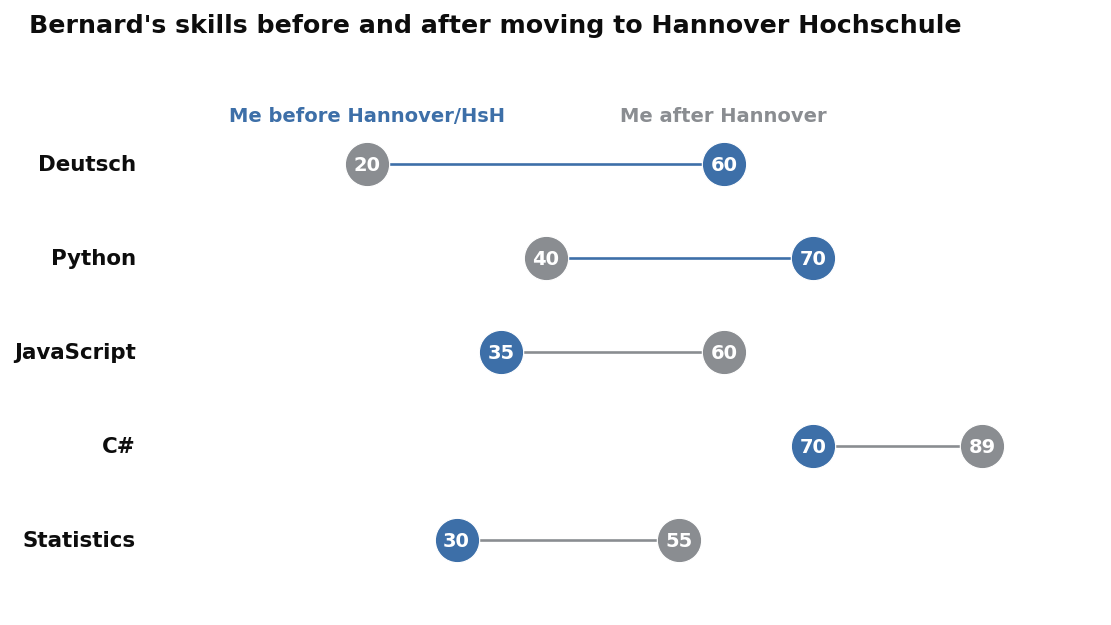

In [5]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
        "font.size": 11,
    }
)

BLUE = "#3d6fa8"
GREY = "#8a8d91"

traits = [
    "Deutsch",
    "Python",
    "JavaScript",
    "C#",
    "Statistics"
]
friend = np.array([20, 40, 60, 89, 55])
me = np.array([60, 70, 35, 70, 30])

n = len(traits)
y = np.arange(n)[::-1]  # top row = Extraversion
r_dot = 520  # marker area (points^2); tune for figure size

fig, ax = plt.subplots(figsize=(8.2, 4.6), dpi=140)
ax.set_facecolor("white")

for yi, tr, fv, mv in zip(y, traits, friend, me):
    lo, hi = sorted((fv, mv))
    # Connector colour = colour of the *higher* score (blue = Me, grey = Friend)
    line_color = BLUE if mv > fv else GREY
    ax.plot([lo, hi], [yi, yi], solid_capstyle="round", color=line_color, linewidth=1.35, zorder=1)
    ax.scatter([fv], [yi], s=r_dot, c=GREY, zorder=3, edgecolors="white", linewidth=0.6)
    ax.scatter([mv], [yi], s=r_dot, c=BLUE, zorder=3, edgecolors="white", linewidth=0.6)
    ax.text(fv, yi, str(int(fv)), ha="center", va="center", color="white", fontweight="bold", fontsize=10, zorder=4)
    ax.text(mv, yi, str(int(mv)), ha="center", va="center", color="white", fontweight="bold", fontsize=10, zorder=4)
    ax.text(-6, yi, tr, ha="right", va="center", fontweight="bold", color="0.05", fontsize=11)

# Integrated header on the first row (Extraversion)
y0 = y[0]
ax.text(friend[0], y0 + 0.42, "Me before Hannover/HsH", ha="center", va="bottom", color=BLUE, fontsize=10, fontweight="semibold")
ax.text(me[0], y0 + 0.42, "Me after Hannover", ha="center", va="bottom", color=GREY, fontsize=10, fontweight="semibold")

ax.set_title(
    "Bernard's skills before and after moving to Hannover Hochschule",
    loc="left",
    fontsize=13,
    fontweight="bold",
    color="0.05",
    pad=22,
)

for s in ax.spines.values():
    s.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.set_xlim(-18, 102)
ax.set_ylim(y.min() - 0.75, y.max() + 0.95)

plt.tight_layout()
plt.show()

## Notes

- **Connector colour** follows the original rule: same hue as whoever has the **higher** score on that trait.
- **Openness** / **Neuroticism**: scores are close, so dots nearly touch — the segment is still drawn underneath.
- Adjust `r_dot` if labels feel tight on your display DPI.